# Cell Morphology Classifier
**Pipeline:** Load CSVs → Filter → Batch correction → PCA → Random Forest

Run cells top to bottom. Only change the parameters in Cell 1.

In [3]:
# ============================================================
# CELL 1 — PARAMETERS  (only edit this cell)
# ============================================================

# Folder containing your nuclei_measurements CSV files (searched recursively)
CSV_DIR = "/Users/giuliaam/Desktop/Newlife/ML_Project/CompoundsData/OutputCP/V3"

# Folder where plots will be saved
OUTPUT_DIR = "/Users/giuliaam/Desktop/Newlife/ML_Project/CompoundsData/OutputCP/V5/classifierOutput"

# Minimum cells per condition to be included
# Conditions below this are dropped automatically
MIN_CELLS_PER_CONDITION = 8

# Features to use — update this list when you add new features
# v4/v5: uncomment the texture and fiber blocks when you have the new CSV
FEATURE_COLS = [
    # --- Morphology (always available) ---
    "Area_um2",
    "Equivalent_diameter_um",
    "Perimeter_um",
    "Eccentricity",
    "Solidity",
    "Orientation_rad",
    # --- Intensity (always available) ---
    "DAPI_mean_intensity",
    "DAPI_integrated_intensity",
    "Actin_mean_intensity",
    # --- DAPI texture (available from v4 onwards) ---
    # "DAPI_contrast",
    # "DAPI_homogeneity",
    # "DAPI_energy",
    # "DAPI_correlation",
    # --- Actin texture (available from v4 onwards) ---
    # "Actin_contrast",
    # "Actin_homogeneity",
    # "Actin_energy",
    # "Actin_correlation",
    # --- Fiber features (available from v5 onwards) ---
    # "fiber_density",
    # "fiber_anisotropy",
    # "fiber_mean_angle",
    # "fiber_orientation_std",
    # "n_fibers",
]

# Random Forest
N_TREES      = 200
N_FOLDS      = 5
RANDOM_STATE = 42

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Parameters set ✓")
print(f"Using {len(FEATURE_COLS)} features")

Parameters set ✓
Using 9 features


In [4]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

print("Imports done ✓")

Imports done ✓


In [5]:
# ============================================================
# CELL 3 — LOAD AND MERGE ALL CSV FILES
# ============================================================

csv_files = sorted(glob.glob(f"{CSV_DIR}/**/*measurements*.csv", recursive=True))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f"  - {Path(f).name}")

if len(csv_files) == 0:
    raise FileNotFoundError(f"No CSV files found in {CSV_DIR}")

dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    # Add replicate column from filename if not already present
    if 'Replicate' not in tmp.columns:
        tmp['Replicate'] = Path(f).stem
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

print(f"\nTotal cells loaded: {len(df)}")
print("\nCells per condition:")
print(df.groupby('Condition').size().sort_values(ascending=False))
print("\nCells per replicate:")
print(df.groupby('Replicate').size())

Found 7 CSV files:
  - 241016_nuclei_measurements.csv
  - 241017_nuclei_measurements.csv
  - 241018MaxProj_nuclei_measurements.csv
  - 241110MaxProj_nuclei_measurements.csv
  - 250416_nuclei_measurements.csv
  - 250523_nuclei_measurements.csv
  - 251002_nuclei_measurements.csv

Total cells loaded: 394

Cells per condition:
Condition
DMSO      115
CytoD     113
Blebbi     50
LatA       45
Noco       35
CK666      30
NCS         4
ML1         1
Y27632      1
dtype: int64

Cells per replicate:
Replicate
241016            32
241017            25
250416            95
250523            54
251002           106
241018MaxProj     25
241110MaxProj     57
dtype: int64


In [6]:
# ============================================================
# CELL 4 — FILTER CONDITIONS WITH TOO FEW CELLS
# ============================================================

counts = df.groupby('Condition').size()
valid_conditions = counts[counts >= MIN_CELLS_PER_CONDITION].index.tolist()
dropped          = counts[counts <  MIN_CELLS_PER_CONDITION].index.tolist()

print(f"Keeping  (>= {MIN_CELLS_PER_CONDITION} cells): {valid_conditions}")
print(f"Dropping (<  {MIN_CELLS_PER_CONDITION} cells): {dropped}")

df_filtered = df[df['Condition'].isin(valid_conditions)].copy()
print(f"\nCells after filtering: {len(df_filtered)}")

# Check which features are actually present in the CSV
missing = [f for f in FEATURE_COLS if f not in df_filtered.columns]
if missing:
    print(f"\nWARNING — these features are not in the CSV yet: {missing}")
    print("Comment them out in FEATURE_COLS in Cell 1 or run the v4/v5 segmentation script first.")
    FEATURE_COLS_USED = [f for f in FEATURE_COLS if f in df_filtered.columns]
else:
    FEATURE_COLS_USED = FEATURE_COLS

print(f"\nFeatures used: {len(FEATURE_COLS_USED)}")

Keeping  (>= 8 cells): ['Blebbi', 'CK666', 'CytoD', 'DMSO', 'LatA', 'Noco']
Dropping (<  8 cells): ['ML1', 'NCS', 'Y27632']

Cells after filtering: 388

Features used: 9


Condition x Replicate table:
Condition      Blebbi  CK666  CytoD  DMSO  LatA  Noco
Replicate                                            
241016              0      0      0    13    10     9
241017              0      4     10     4     5     2
250416             10     12     17    20    17    19
250523             39      0      0    15     0     0
251002              0      0     67    39     0     0
241018MaxProj       0      4     10     4     5     2
241110MaxProj       1     10      9    20     8     3


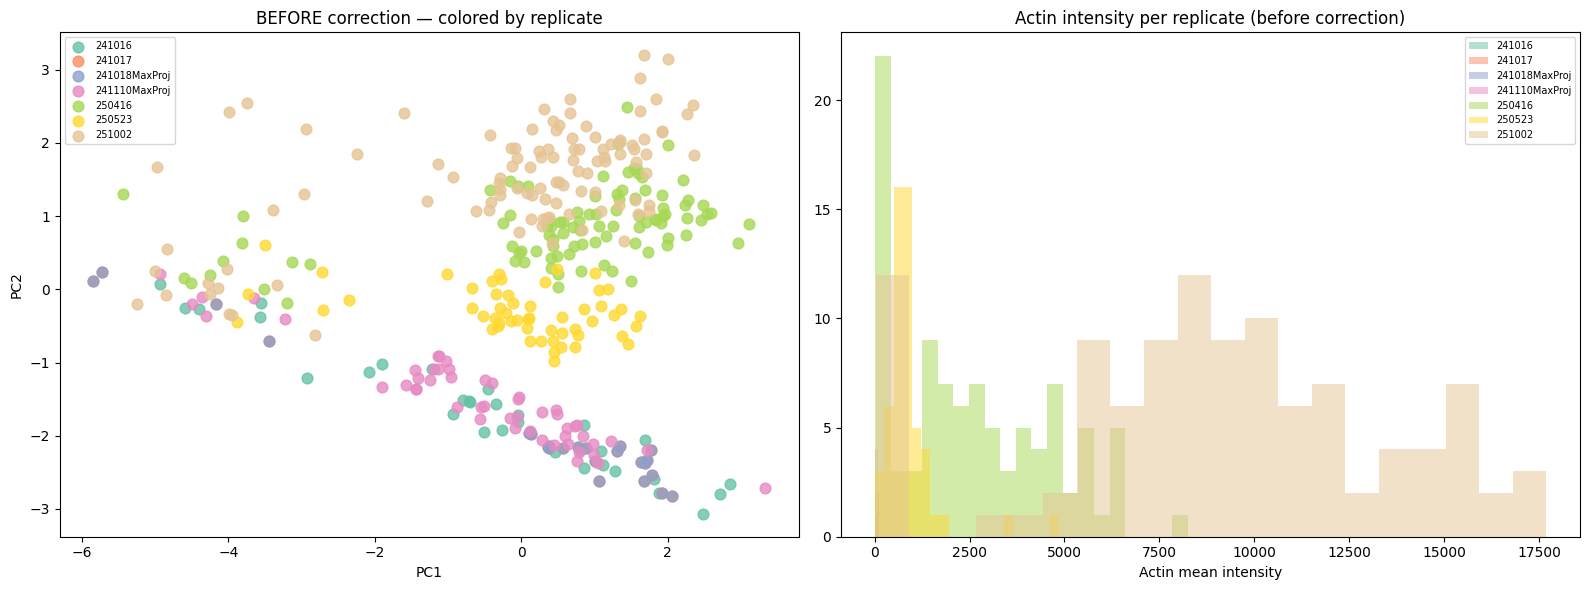

In [7]:
# ============================================================
# CELL 5 — BATCH EFFECT DIAGNOSIS
# ============================================================

print("Condition x Replicate table:")
pivot = df_filtered.groupby(['Replicate', 'Condition']).size().unstack(fill_value=0)
print(pivot)

# Quick PCA colored by replicate to visualize batch effect
from sklearn.preprocessing import StandardScaler
X_raw = df_filtered[FEATURE_COLS_USED].values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

pca_diag = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_diag = pca_diag.fit_transform(X_raw_scaled)

unique_reps = df_filtered['Replicate'].unique()
palette_rep = sns.color_palette("Set2", len(unique_reps))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — by replicate
for i, rep in enumerate(unique_reps):
    mask = df_filtered['Replicate'] == rep
    axes[0].scatter(X_pca_diag[mask, 0], X_pca_diag[mask, 1],
                    label=rep, color=palette_rep[i], s=60, alpha=0.8)
axes[0].set_title("BEFORE correction — colored by replicate")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=7)

# Right — actin intensity histograms per replicate
for i, rep in enumerate(unique_reps):
    mask = df_filtered['Replicate'] == rep
    axes[1].hist(df_filtered[mask]['Actin_mean_intensity'],
                 bins=20, alpha=0.5, label=rep, color=palette_rep[i])
axes[1].set_title("Actin intensity per replicate (before correction)")
axes[1].set_xlabel("Actin mean intensity")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/batch_diagnosis.png", dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# CELL 6 — BATCH CORRECTION (DMSO-anchored z-score)
# ============================================================
# For each replicate:
#   1. Compute mean and std of DMSO cells (the control anchor)
#   2. Subtract mean, divide by std for ALL cells in that replicate
# Result: drug effects expressed as deviations from DMSO baseline

df_corrected = df_filtered.copy()

for replicate in df_filtered['Replicate'].unique():
    dmso_mask = (
        (df_filtered['Replicate'] == replicate) &
        (df_filtered['Condition'] == 'DMSO')
    )

    if dmso_mask.sum() == 0:
        print(f"WARNING: No DMSO cells in replicate {replicate} — skipping correction for this replicate")
        continue

    dmso_cells = df_filtered[dmso_mask][FEATURE_COLS_USED]
    dmso_mean  = dmso_cells.mean()
    dmso_std   = dmso_cells.std()
    dmso_std[dmso_std < 1e-8] = 1.0  # avoid division by zero

    rep_mask = df_filtered['Replicate'] == replicate
    df_corrected.loc[rep_mask, FEATURE_COLS_USED] = (
        (df_filtered.loc[rep_mask, FEATURE_COLS_USED] - dmso_mean) / dmso_std
    )

print("Batch correction applied ✓")
print("\nDMSO cells used as reference per replicate:")
print(df_filtered[df_filtered['Condition'] == 'DMSO'].groupby('Replicate').size())

Batch correction applied ✓

DMSO cells used as reference per replicate:
Replicate
241016           13
241017            4
250416           20
250523           15
251002           39
241018MaxProj     4
241110MaxProj    20
dtype: int64


In [9]:
# ============================================================
# CELL 7 — PREPARE FEATURE MATRIX
# ============================================================

X = df_corrected[FEATURE_COLS_USED].values
y = df_corrected['Condition'].values

le = LabelEncoder()
y_encoded  = le.fit_transform(y)
class_names = le.classes_

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Color palette — one color per condition, reused in all plots
palette   = sns.color_palette("tab10", len(class_names))
color_map = {cond: palette[i] for i, cond in enumerate(class_names)}

print(f"Feature matrix: {X_scaled.shape}")
print(f"Classes: {class_names}")

Feature matrix: (388, 9)
Classes: ['Blebbi' 'CK666' 'CytoD' 'DMSO' 'LatA' 'Noco']


PCA explained variance: PC1=52.1%, PC2=13.3%


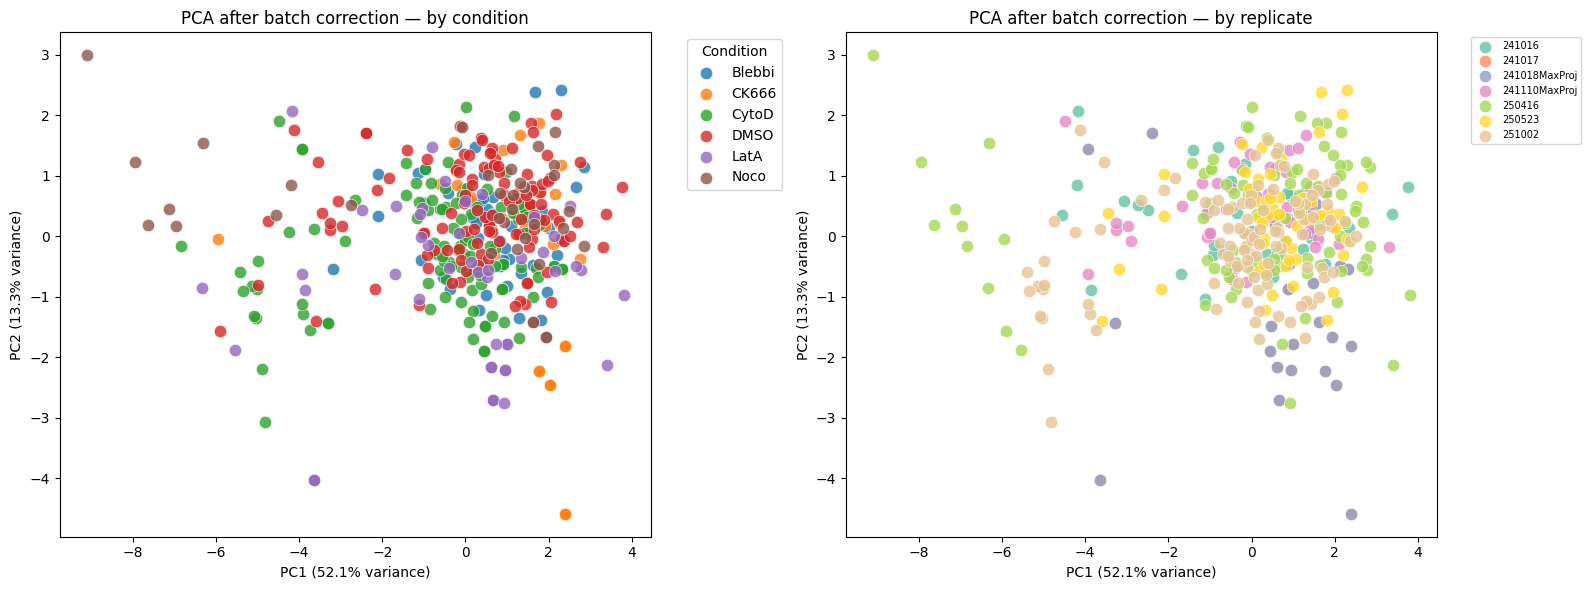

PCA saved ✓


In [10]:
# ============================================================
# CELL 8 — PCA VISUALIZATION
# ============================================================

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

print(f"PCA explained variance: PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — by condition
for cond in class_names:
    mask = df_corrected['Condition'] == cond
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=cond, color=color_map[cond],
                    s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[0].set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
axes[0].set_title("PCA after batch correction — by condition")
axes[0].legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')

# Right — by replicate (sanity check: should be well mixed after correction)
unique_reps = df_corrected['Replicate'].unique()
palette_rep = sns.color_palette("Set2", len(unique_reps))
for i, rep in enumerate(unique_reps):
    mask = df_corrected['Replicate'] == rep
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=rep, color=palette_rep[i],
                    s=80, alpha=0.8, edgecolors='white', linewidths=0.5)
axes[1].set_xlabel(f"PC1 ({explained[0]:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({explained[1]:.1f}% variance)")
axes[1].set_title("PCA after batch correction — by replicate")
axes[1].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pca_corrected.png", dpi=150, bbox_inches='tight')
plt.show()
print("PCA saved ✓")

PCA loadings (which features drive separation):
                             PC1    PC2
Equivalent_diameter_um     0.449  0.036
Area_um2                   0.443  0.042
Perimeter_um               0.443  0.081
DAPI_integrated_intensity  0.434  0.003
Solidity                   0.311 -0.180
DAPI_mean_intensity        0.302  0.064
Eccentricity              -0.123  0.569
Actin_mean_intensity       0.106  0.605
Orientation_rad            0.058 -0.513


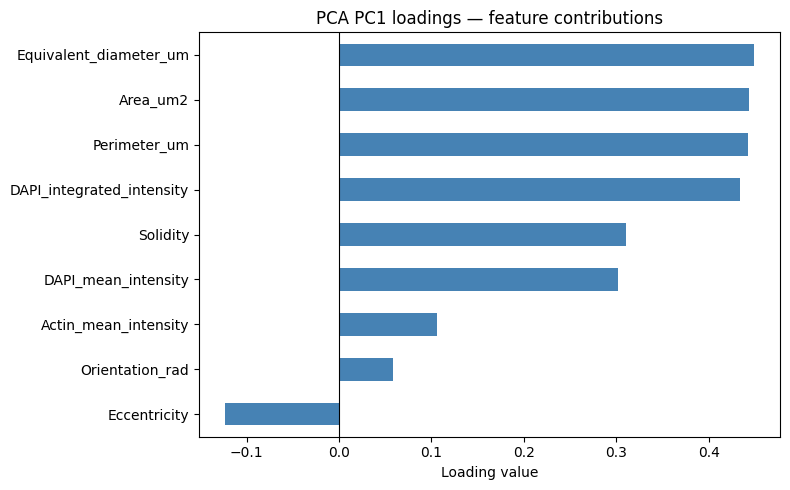

In [11]:
# ============================================================
# CELL 9 — PCA LOADINGS
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS_USED,
    columns=['PC1', 'PC2']
).sort_values('PC1', key=abs, ascending=False)

print("PCA loadings (which features drive separation):")
print(loadings.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
loadings['PC1'].sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("PCA PC1 loadings — feature contributions")
ax.set_xlabel("Loading value")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pca_loadings.png", dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ============================================================
# CELL 10 — RANDOM FOREST CLASSIFIER
# ============================================================

rf = RandomForestClassifier(
    n_estimators=N_TREES,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Running {N_FOLDS}-fold stratified cross-validation...")
y_pred = cross_val_predict(rf, X_scaled, y_encoded, cv=cv)

y_pred_labels = le.inverse_transform(y_pred)
y_true_labels = le.inverse_transform(y_encoded)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true_labels, y_pred_labels))

Running 5-fold stratified cross-validation...

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Blebbi       0.62      0.40      0.49        50
       CK666       0.61      0.47      0.53        30
       CytoD       0.58      0.68      0.63       113
        DMSO       0.49      0.58      0.53       115
        LatA       0.69      0.56      0.62        45
        Noco       0.64      0.51      0.57        35

    accuracy                           0.57       388
   macro avg       0.61      0.53      0.56       388
weighted avg       0.58      0.57      0.57       388



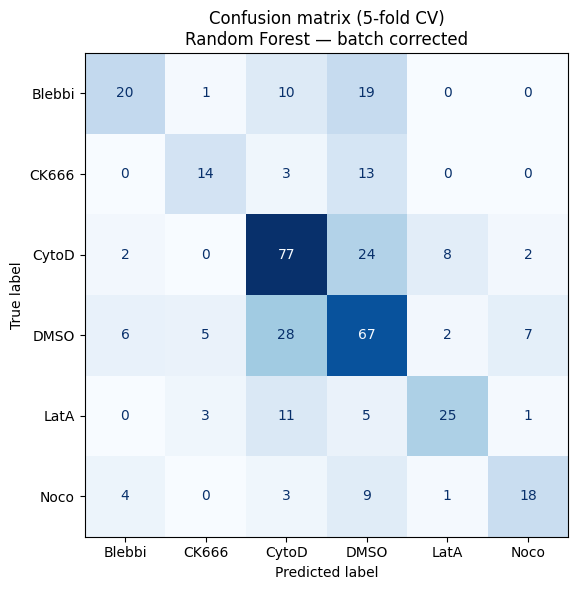

Confusion matrix saved ✓


In [13]:
# ============================================================
# CELL 11 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true_labels, y_pred_labels, labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"Confusion matrix ({N_FOLDS}-fold CV)\nRandom Forest — batch corrected")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved ✓")

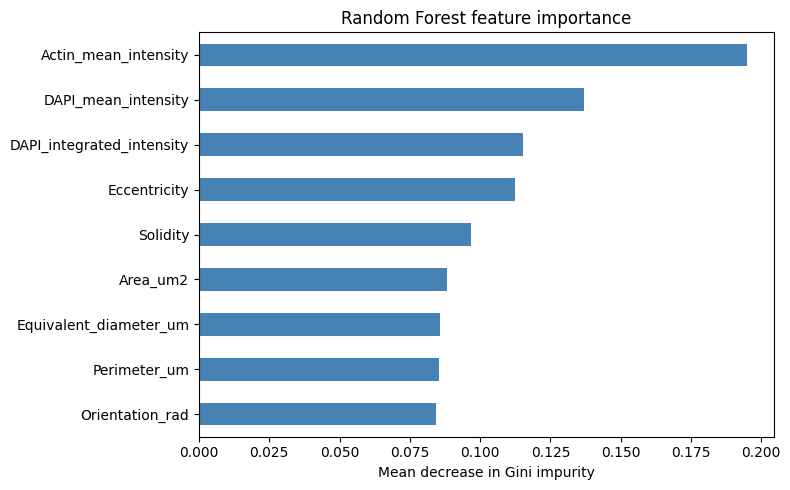


=== TOP 5 MOST IMPORTANT FEATURES ===
Actin_mean_intensity         0.1948
DAPI_mean_intensity          0.1371
DAPI_integrated_intensity    0.1153
Eccentricity                 0.1124
Solidity                     0.0967
dtype: float64


In [14]:
# ============================================================
# CELL 12 — FEATURE IMPORTANCE
# ============================================================

# Fit on full dataset to get stable importances
rf.fit(X_scaled, y_encoded)
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS_USED)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, max(5, len(FEATURE_COLS_USED) * 0.4)))
importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Mean decrease in Gini impurity")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n=== TOP 5 MOST IMPORTANT FEATURES ===")
print(importances.sort_values(ascending=False).head(5).round(4))